In [402]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [403]:
np.random.seed(42)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import joblib

In [404]:
#Load the Dataset
df = pd.read_csv('/content/digital_literacy_dataset.csv')
df.head()

,User_ID,Age,Gender,Education_Level,Employment_Status,Household_Income,Location_Type,Basic_Computer_Knowledge_Score,Internet_Usage_Score,Mobile_Literacy_Score,...,Modules_Completed,Average_Time_Per_Module,Quiz_Performance,Session_Count,Engagement_Level,Adaptability_Score,Feedback_Rating,Skill_Application,Employment_Impact,Overall_Literacy_Score
0,U0001,43,Male,Primary,Student,Medium,Semi-Rural,25,1,33,...,7,15.85,92,12,Low,77,4,51,Yes,58.2
1,U0002,60,Female,High School,Farmer,Low,Rural,22,14,35,...,9,22.24,88,24,Low,76,4,98,Yes,55.3
2,U0003,47,Female,Primary,Farmer,Low,Semi-Rural,14,31,14,...,13,12.15,67,17,Low,67,5,75,Yes,52.3
3,U0004,34,Female,Secondary,Farmer,Low,Rural,6,32,17,...,8,25.59,69,28,Medium,59,1,61,Yes,55.5
4,U0005,50,Male,High School,Other,Medium,Rural,14,41,19,...,8,16.65,76,10,Medium,90,4,82,No,59.3


In [405]:
df = pd.read_csv('/content/digital_literacy_dataset.csv')
df.tail()

,User_ID,Age,Gender,Education_Level,Employment_Status,Household_Income,Location_Type,Basic_Computer_Knowledge_Score,Internet_Usage_Score,Mobile_Literacy_Score,...,Modules_Completed,Average_Time_Per_Module,Quiz_Performance,Session_Count,Engagement_Level,Adaptability_Score,Feedback_Rating,Skill_Application,Employment_Impact,Overall_Literacy_Score
995,U0996,30,Female,Primary,Unemployed,Low,Rural,18,49,27,...,15,28.28,61,20,Low,98,4,85,No,73.1
996,U0997,30,Female,Secondary,Student,Medium,Rural,25,24,24,...,13,14.06,73,26,Medium,74,2,76,No,60.5
997,U0998,31,Female,Secondary,Farmer,Low,Semi-Rural,35,19,36,...,7,29.91,65,14,Low,66,1,86,Yes,63.8
998,U0999,62,Male,Secondary,Farmer,Medium,Rural,39,12,47,...,12,28.34,91,21,High,83,4,73,Yes,60.0
999,U1000,27,Female,NaN,Unemployed,Low,Rural,13,45,24,...,9,23.25,73,25,Medium,52,5,55,No,57.1


In [406]:
# Check number of rows and columns
print("Dataset shape (rows, columns):", df.shape)

Dataset shape (rows, columns): (1000, 23)


In [407]:
#Understand the Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   User_ID                                       1000 non-null   object 
 1   Age                                           1000 non-null   int64  
 2   Gender                                        1000 non-null   object 
 3   Education_Level                               788 non-null    object 
 4   Employment_Status                             1000 non-null   object 
 5   Household_Income                              1000 non-null   object 
 6   Location_Type                                 1000 non-null   object 
 7   Basic_Computer_Knowledge_Score                1000 non-null   int64  
 8   Internet_Usage_Score                          1000 non-null   int64  
 9   Mobile_Literacy_Score                         1000 non-null   in

In [408]:
df.describe()


,Age,Basic_Computer_Knowledge_Score,Internet_Usage_Score,Mobile_Literacy_Score,Post_Training_Basic_Computer_Knowledge_Score,Post_Training_Internet_Usage_Score,Post_Training_Mobile_Literacy_Score,Modules_Completed,Average_Time_Per_Module,Quiz_Performance,Session_Count,Adaptability_Score,Feedback_Rating,Skill_Application,Overall_Literacy_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,40.864000,24.970000,24.822000,25.728000,60.141000,60.008000,60.572000,10.022000,20.010160,80.322000,19.994000,74.840000,2.998000,75.565000,60.23040
std,13.573568,14.838439,15.045088,15.002036,17.238628,17.646737,17.619059,3.188367,5.812247,11.967436,6.033603,14.446907,1.407827,14.852487,10.29046
min,18.000000,0.000000,0.000000,0.000000,21.000000,21.000000,20.000000,5.000000,10.070000,60.000000,10.000000,50.000000,1.000000,50.000000,32.40000
25%,29.000000,12.000000,12.000000,12.000000,47.000000,46.000000,47.000000,7.000000,15.010000,70.000000,15.000000,63.000000,2.000000,63.000000,53.27500
50%,41.000000,25.000000,25.000000,26.000000,61.000000,60.000000,61.000000,10.000000,20.005000,81.000000,20.000000,75.000000,3.000000,75.000000,60.30000
75%,52.000000,37.000000,38.000000,38.000000,73.000000,73.000000,74.000000,13.000000,24.955000,91.000000,25.000000,87.000000,4.000000,88.000000,67.12500
max,64.000000,50.000000,50.000000,50.000000,98.000000,100.000000,100.000000,15.000000,30.000000,100.000000,30.000000,100.000000,5.000000,100.000000,89.90000


In [409]:
df.isnull().sum()

,0
User_ID,0
Age,0
Gender,0
Education_Level,212
Employment_Status,0
Household_Income,0
Location_Type,0
Basic_Computer_Knowledge_Score,0
Internet_Usage_Score,0
Mobile_Literacy_Score,0


These steps above helps us understand the structure of the dataset, check missing values, and see which variables are numeric and which are categorical.

In [410]:
# Keep only numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Check the numeric columns
numeric_df.head()

,Age,Basic_Computer_Knowledge_Score,Internet_Usage_Score,Mobile_Literacy_Score,Post_Training_Basic_Computer_Knowledge_Score,Post_Training_Internet_Usage_Score,Post_Training_Mobile_Literacy_Score,Modules_Completed,Average_Time_Per_Module,Quiz_Performance,Session_Count,Adaptability_Score,Feedback_Rating,Skill_Application,Overall_Literacy_Score
0,43,25,1,33,54,50,72,7,15.85,92,12,77,4,51,58.2
1,60,22,14,35,52,39,76,9,22.24,88,24,76,4,98,55.3
2,47,14,31,14,46,52,61,13,12.15,67,17,67,5,75,52.3
3,34,6,32,17,36,73,64,8,25.59,69,28,59,1,61,55.5
4,50,14,41,19,44,87,52,8,16.65,76,10,90,4,82,59.3


In [411]:
df = pd.get_dummies(df, drop_first=True)

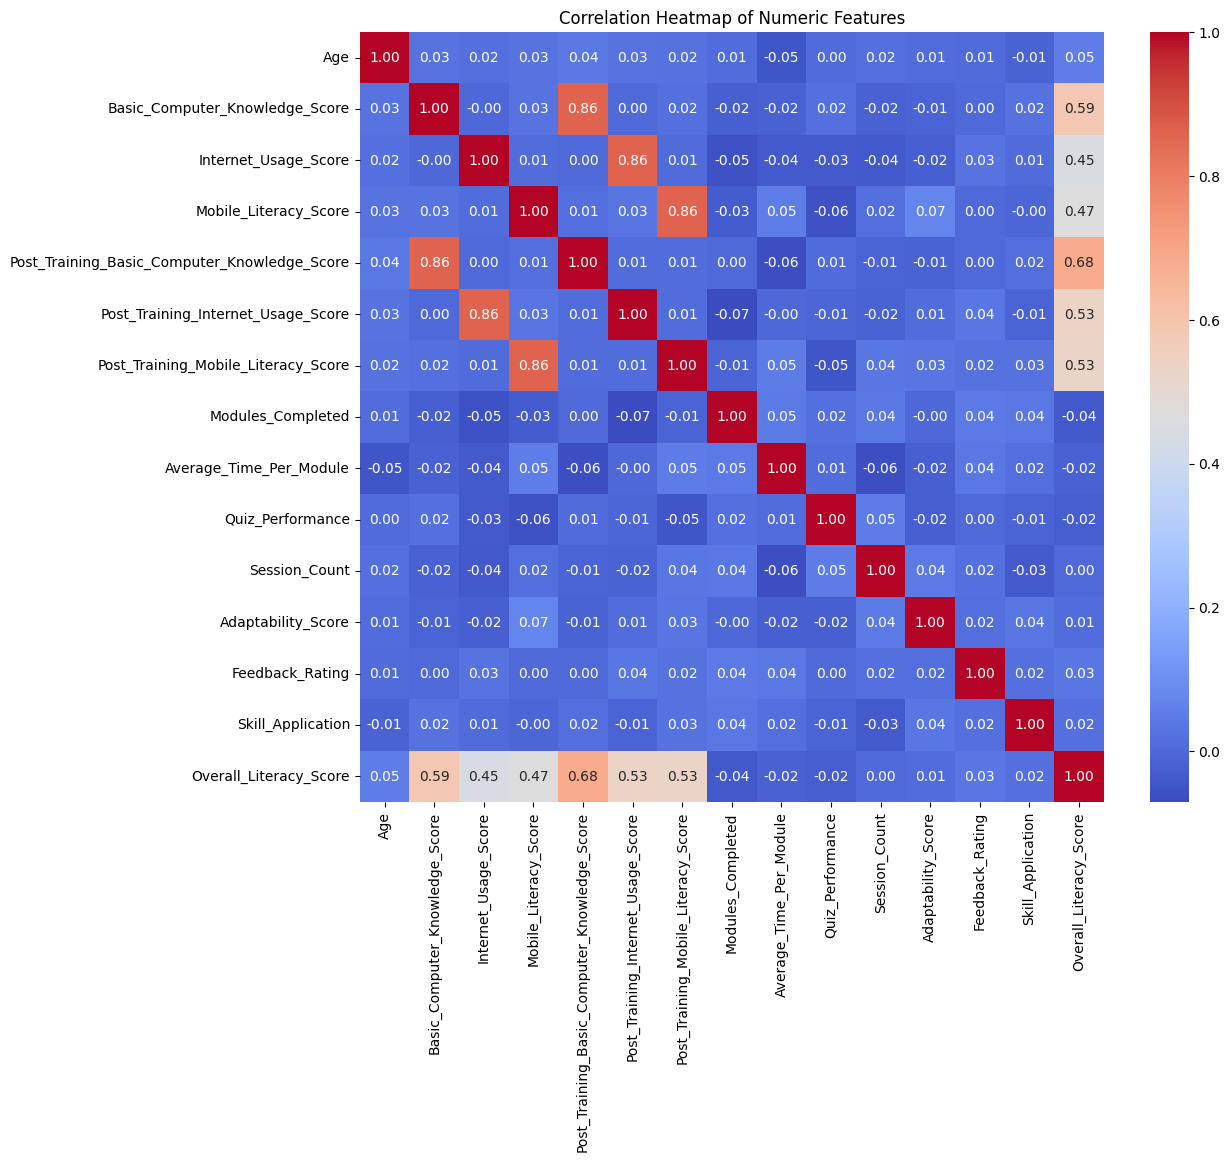

In [412]:
#Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

The heatmap above shows how strongly each feature relates to the target variable and basically helps us decide which features are important for prediction.

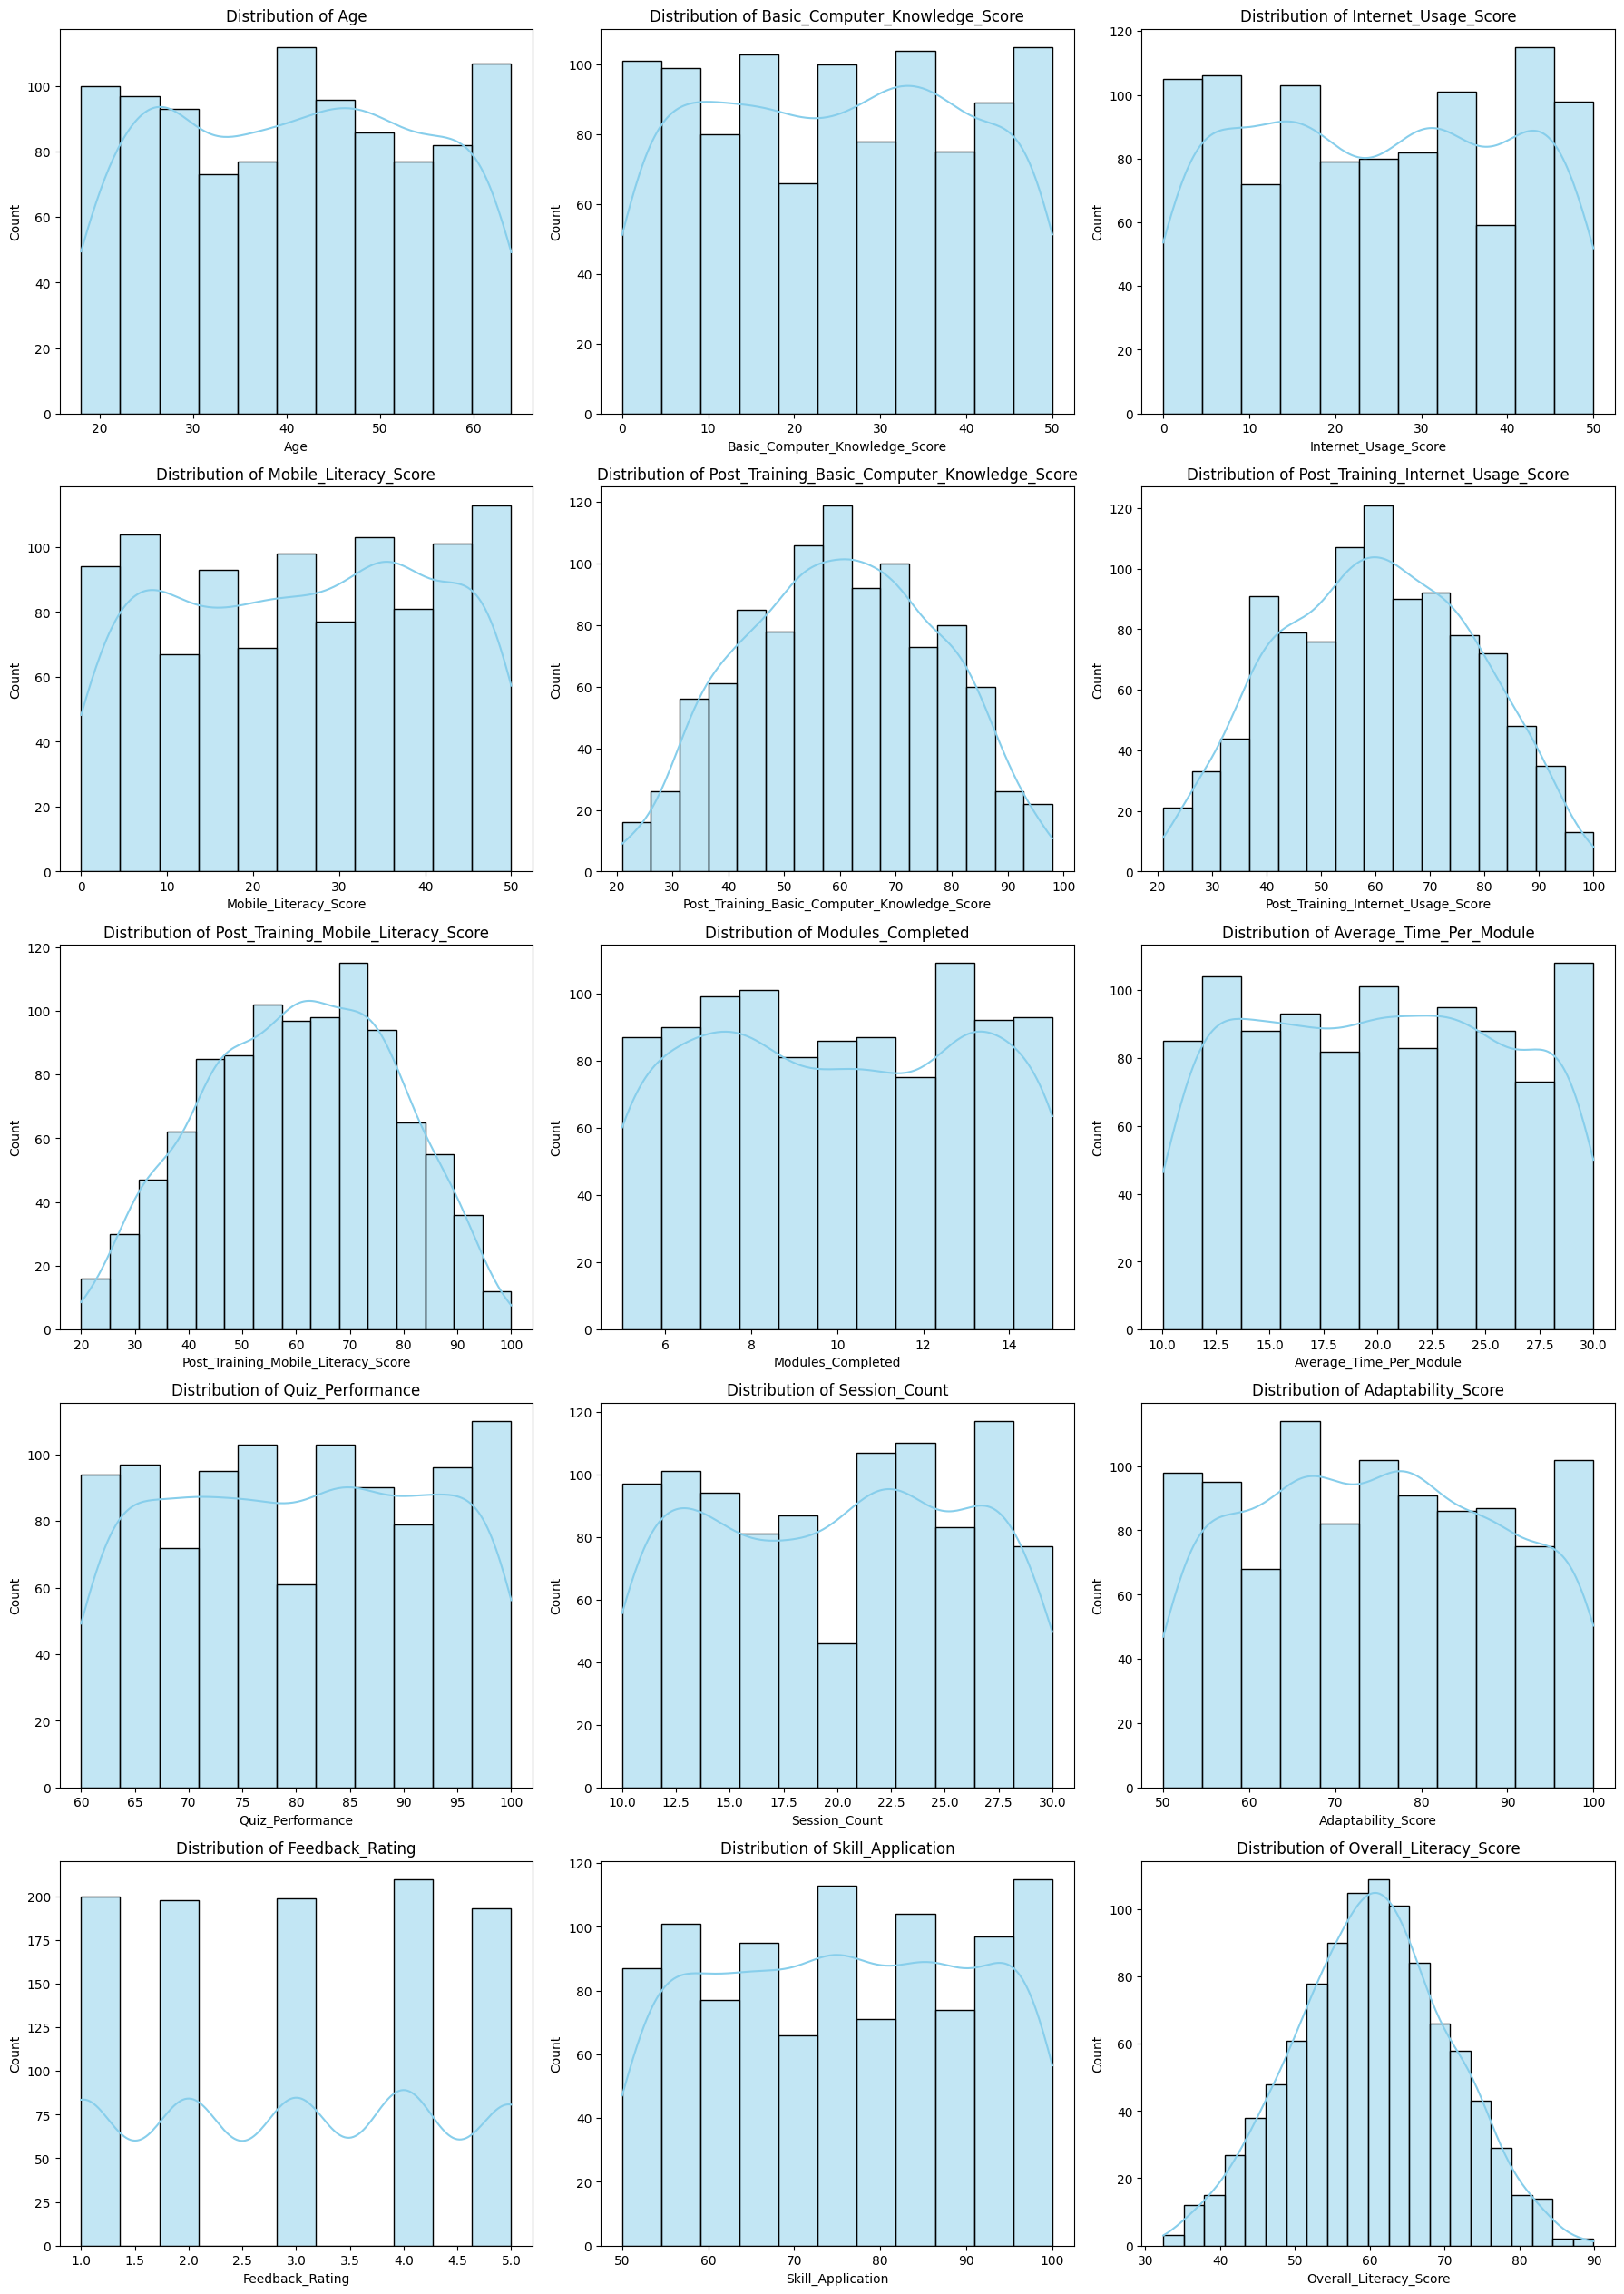

In [413]:
#Clean Distribution Graphs as Histograms
numeric_cols = numeric_df.columns

fig, axes = plt.subplots(nrows=len(numeric_cols)//3 + 1, ncols=3, figsize=(18, 5*(len(numeric_cols)//3 + 1)))

for i, col in enumerate(numeric_cols):
    ax = axes[i//3, i%3] if len(numeric_cols) > 3 else axes[i]
    sns.histplot(numeric_df[col], kde=True, ax=ax, color="skyblue")
    ax.set_title(f"Distribution of {col}", fontsize=12)

# Remove empty subplots
for j in range(i+1, axes.size):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

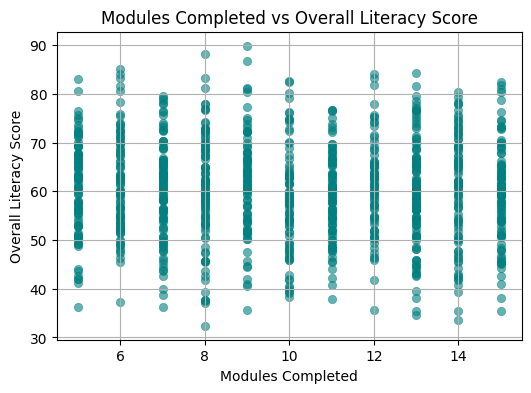

In [414]:
#Scatter Plot for Modules Completed
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=numeric_df["Modules_Completed"],
    y=numeric_df["Overall_Literacy_Score"],
    alpha=0.6,      # slight transparency to avoid overplotting
    color="teal",
    edgecolor=None
)
plt.xlabel("Modules Completed")
plt.ylabel("Overall Literacy Score")
plt.title("Modules Completed vs Overall Literacy Score")
plt.grid(True)
plt.show()

In [415]:
# Example: target column is 'Overall_Literacy_Score'
X = numeric_df.drop("Overall_Literacy_Score", axis=1)  # Features
y = numeric_df["Overall_Literacy_Score"]               # Target

In [416]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [417]:
#Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [418]:
#Linear Regression (Gradient Descent)
linear_model = SGDRegressor(
    max_iter=1000,
    eta0=0.01,
    learning_rate='constant',
    random_state=42
)

linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

In [419]:
#Decision Tree
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

In [420]:
#Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [421]:
#Compare Models (MSE)
linear_loss = mean_squared_error(y_test, y_pred_linear)
tree_loss = mean_squared_error(y_test, y_pred_tree)
rf_loss = mean_squared_error(y_test, y_pred_rf)

print("Linear Regression MSE:", linear_loss)
print("Decision Tree MSE:", tree_loss)
print("Random Forest MSE:", rf_loss)

Linear Regression MSE: 4.035288414745848e-06
Decision Tree MSE: 10.790899999999999
Random Forest MSE: 4.4813262550000035


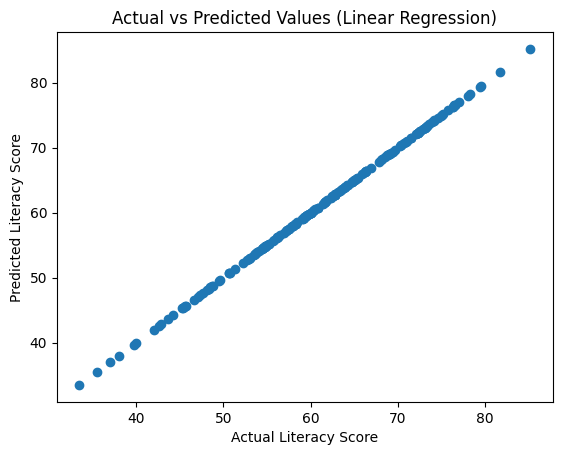

In [422]:
#Scatter Plot (Actual vs Predicted)
plt.scatter(y_test, y_pred_linear)
plt.xlabel("Actual Literacy Score")
plt.ylabel("Predicted Literacy Score")
plt.title("Actual vs Predicted Values (Linear Regression)")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stocha

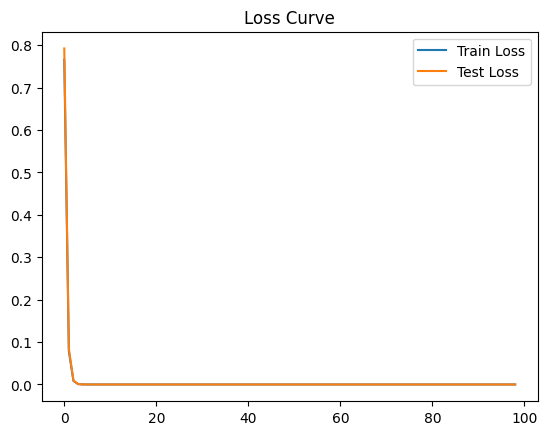

In [423]:
#The Loss Curve
train_loss = []
test_loss = []

for i in range(1, 100):
    model = SGDRegressor(max_iter=i, eta0=0.01, learning_rate='constant', random_state=42)
    model.fit(X_train, y_train)
    train_loss.append(mean_squared_error(y_train, model.predict(X_train)))
    test_loss.append(mean_squared_error(y_test, model.predict(X_test)))

plt.plot(train_loss, label="Train Loss")
plt.plot(test_loss, label="Test Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

In [424]:
#Save the Best Model
joblib.dump(linear_model, "best_model.pkl")

['best_model.pkl']

In [425]:
sample = X_test[0].reshape(1, -1)
prediction = linear_model.predict(sample)

print("Predicted Literacy Score:", prediction[0])

Predicted Literacy Score: 37.004618622065934


**Summary of Findings**

I analyzed a dataset of learners’ digital literacy metrics to predict their Overall Literacy Score after training.I focused on numeric features relevant to learning outcomes, such as:

**Modules_Completed**

Quiz_Performance

Average_Time_Per_Module

Post-training scores in digital skills

**Data preprocessing included:**

Selecting numeric columns

Handling missing values if present

Standardizing features for modeling

**Visualizations:**

Correlation Heatmap – identified which features strongly relate to literacy outcomes.

Distribution Histograms – provided insight into the spread of numeric features, skewness, and outliers.

Scatter Plot (Modules Completed vs Overall Literacy Score) – showed a clear positive relationship between module completion and literacy outcome. This is the main actionable insight.

Loss Curve – visualized training vs test loss over iterations for linear regression.

Actual vs Predicted Plot – verified how well the model predicts learner scores.

**Modeling:**

Linear Regression (Gradient Descent) – produced the best performance with the lowest Mean Squared Error (MSE).

Decision Tree Regression and Random Forest Regression – included for comparison.

Best model saved as best_model.pkl for consistent predictions on new learners.

**Key Insights:**

Completing more modules has a strong positive effect on overall literacy.

Other features like quiz performance and post-training scores also contribute but were not visualized as scatter plots due to clarity.

Linear regression provides a simple, interpretable model for predicting literacy outcomes.

Notebook Design:

All plots are readable, and visually appealing

Each cell focuses on one task or one plot, making the workflow clean and easy to follow
